# Global Setup & Imports

In [1]:
# Install necessary libraries
# !pip install torch torchvision transformers peft datasets bitsandbytes accelerate scikit-learn matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import os
from PIL import Image
import glob
import bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [41]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.5 MB/s eta 0:00:00


# Part 1: Image Re-identification (Transformers)

### 1.1 Data Preparation (Dataset & Augmentation)

In [2]:
# Download Market-1501 dataset for Re-ID
import urllib.request
import zipfile
import os

import kagglehub

# Download latest version
data_path = kagglehub.dataset_download("pengcw1/market-1501")

print(f"Dataset path: {data_path}")

100%|██████████| 146M/146M [00:08<00:00, 18.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/pengcw1/market-1501/versions/1


In [3]:
!wget https://data.bris.ac.uk/datasets/2yizcfbkuv4352pzc32n54371r/2yizcfbkuv4352pzc32n54371r.zip

--2026-01-04 15:20:01--  https://data.bris.ac.uk/datasets/2yizcfbkuv4352pzc32n54371r/2yizcfbkuv4352pzc32n54371r.zip
Resolving data.bris.ac.uk (data.bris.ac.uk)... 137.222.0.78
Connecting to data.bris.ac.uk (data.bris.ac.uk)|137.222.0.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 342789520 (327M) [application/zip]
Saving to: ‘2yizcfbkuv4352pzc32n54371r.zip’

2yizcfbkuv4352pzc32 100%[===================>] 326.91M   726KB/s    in 8m 5s   

2026-01-04 15:28:08 (690 KB/s) - ‘2yizcfbkuv4352pzc32n54371r.zip’ saved [342789520/342789520]



In [4]:
!ls

2yizcfbkuv4352pzc32n54371r.zip	sample_data


In [7]:
!unzip 2yizcfbkuv4352pzc32n54371r.zip

Archive:  2yizcfbkuv4352pzc32n54371r.zip
   creating: 2yizcfbkuv4352pzc32n54371r/
   creating: 2yizcfbkuv4352pzc32n54371r/69/
  inflating: 2yizcfbkuv4352pzc32n54371r/69/.footer.html  
  inflating: 2yizcfbkuv4352pzc32n54371r/69/770.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/69/.header.html  
  inflating: 2yizcfbkuv4352pzc32n54371r/readme.txt  
   creating: 2yizcfbkuv4352pzc32n54371r/34/
  inflating: 2yizcfbkuv4352pzc32n54371r/34/424.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/403.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/.footer.html  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/406.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/420.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/390.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/387.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/412.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/409.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/423.jpg  
  inflating: 2yizcfbkuv4352pzc32n54371r/34/393.jpg  
  inflating: 2yizcfb

In [8]:
!ls

2yizcfbkuv4352pzc32n54371r  2yizcfbkuv4352pzc32n54371r.zip  sample_data


In [9]:
cd 2yizcfbkuv4352pzc32n54371r

/content/2yizcfbkuv4352pzc32n54371r


In [12]:
!ls

1   14	19  23	28  32	37  41	46  50	55  6	64  69	73  78	82  87
10  15	2   24	29  33	38  42	47  51	56  60	65  7	74  79	83  88
11  16	20  25	3   34	39  43	48  52	57  61	66  70	75  8	84  89
12  17	21  26	30  35	4   44	49  53	58  62	67  71	76  80	85  9
13  18	22  27	31  36	40  45	5   54	59  63	68  72	77  81	86  readme.txt


In [13]:
!cat readme.txt

FriesianCattle 2017 Dataset
---------------------------
(associated to paper: W Andrew, C Greatwood, T Burghardt. Visual Localisation and Individual Identification of Holstein Friesian Cattle via Deep Learning. Visual Wildlife Monitoring (VWM) Workshop at IEEE International Conference of Computer Vision (ICCVW), October 2017.)

CONTENTS:
940 jpg images organised in folders associated to 89 individual Friesian cattle

FILE FORMAT:
standard jpg images

DESCRIPTION:
Orientation-rectified RGB top down images.

In [17]:
import os
import shutil
import random
from tqdm import tqdm

# ================= CONFIGURATION =================
# 1. The folder name from your screenshot
SOURCE_ROOT = "/content/2yizcfbkuv4352pzc32n54371r"

# 2. Where we will save the clean, split data
DEST_ROOT = "./processed_data"
# =================================================

def split_dataset():
    if not os.path.exists(SOURCE_ROOT):
        print(f"Error: Could not find folder '{SOURCE_ROOT}'. Make sure it is in the current directory.")
        return

    print(f"Processing data from: {SOURCE_ROOT}")

    # Get all cow ID folders (1, 10, 11, 12...)
    # We filter out hidden files like .DS_Store
    class_folders = [d for d in os.listdir(SOURCE_ROOT) if os.path.isdir(os.path.join(SOURCE_ROOT, d))]

    train_count = 0
    test_count = 0

    for class_id in tqdm(class_folders, desc="Splitting Classes"):
        src_class_path = os.path.join(SOURCE_ROOT, class_id)

        # Get all images in this class
        images = [f for f in os.listdir(src_class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Shuffle to ensure random split
        random.shuffle(images)

        # 80/20 Split
        split_idx = int(len(images) * 0.8)
        train_imgs = images[:split_idx]
        test_imgs = images[split_idx:]

        # Create destination folders
        # structure: ./processed_data/train/1/
        train_dest = os.path.join(DEST_ROOT, "train", class_id)
        test_dest = os.path.join(DEST_ROOT, "test", class_id)

        os.makedirs(train_dest, exist_ok=True)
        os.makedirs(test_dest, exist_ok=True)

        # Copy Files
        for img in train_imgs:
            shutil.copy(os.path.join(src_class_path, img), os.path.join(train_dest, img))
            train_count += 1

        for img in test_imgs:
            shutil.copy(os.path.join(src_class_path, img), os.path.join(test_dest, img))
            test_count += 1

    print("\nSuccess! Data organized.")
    print(f"Training Images: {train_count} (Saved in {os.path.join(DEST_ROOT, 'train')})")
    print(f"Testing Images:  {test_count}  (Saved in {os.path.join(DEST_ROOT, 'test')})")

# Run the split
split_dataset()

Processing data from: /content/2yizcfbkuv4352pzc32n54371r


Splitting Classes: 100%|██████████| 89/89 [00:06<00:00, 14.41it/s]


Success! Data organized.
Training Images: 714 (Saved in ./processed_data/train)
Testing Images:  226  (Saved in ./processed_data/test)


In [ ]:
data_path = "/kaggle/input/market-1501/Market-1501-v15.09.15/"

In [20]:
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

class ReIDDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []

        if not os.path.exists(data_path):
            print(f"Error: Path {data_path} not found!")
            return

        # -----------------------------------------------------------
        # MODIFIED LOGIC: Iterate through subfolders (1, 10, 11...)
        # -----------------------------------------------------------
        # Get list of folders (classes)
        folder_names = sorted([d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))])

        for folder_name in folder_names:
            try:
                # The folder name IS the Person/Cow ID
                pid = int(folder_name)
            except ValueError:
                continue # Skip non-integer folders if any exist

            folder_path = os.path.join(data_path, folder_name)

            # Iterate through images inside the folder
            for img_file in os.listdir(folder_path):
                if img_file.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp')):
                    self.image_paths.append(os.path.join(folder_path, img_file))
                    self.labels.append(pid)

        # -----------------------------------------------------------
        # Re-map PIDs to 0-indexed labels for CrossEntropyLoss
        # -----------------------------------------------------------
        # Example: If IDs are [1, 14, 19...], map them to [0, 1, 2...]
        unique_pids = sorted(list(set(self.labels)))
        self.pid_to_label = {pid: i for i, pid in enumerate(unique_pids)}
        self.labels = [self.pid_to_label[pid] for pid in self.labels]
        self.classes = unique_pids

        print(f"Loaded {len(self.image_paths)} images from {data_path}")
        print(f"Found {len(self.classes)} unique identities.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            return torch.zeros(3, 256, 128), self.labels[idx] # Return dummy on fail

        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

# -----------------------------------------------------------
# Your Transforms (Kept the same)
# -----------------------------------------------------------
train_transforms = T.Compose([
    T.Resize((256, 128)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.RandomErasing(p=0.5),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = T.Compose([
    T.Resize((256, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# -----------------------------------------------------------
# Usage
# -----------------------------------------------------------
# Update these paths to where your 'train' and 'test' folders are located
# If you used the script I gave earlier, they are inside ./cow_dataset/
train_path = "/content/2yizcfbkuv4352pzc32n54371r/processed_data/train"
test_path = "/content/2yizcfbkuv4352pzc32n54371r/processed_data/test"

train_dataset = ReIDDataset(train_path, transform=train_transforms)
test_dataset = ReIDDataset(test_path, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Loaded 714 images from /content/2yizcfbkuv4352pzc32n54371r/processed_data/train
Found 84 unique identities.
Loaded 226 images from /content/2yizcfbkuv4352pzc32n54371r/processed_data/test
Found 89 unique identities.


### 1.2 & 1.3 Model Definitions (ResNet & BotNet)

**ResNet50:**

In [21]:
def get_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    # Modify the final layer for Re-ID (classification)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

**BotNet (Bottleneck Transformer):**
This is the core implementation task. We replace the spatial convolutions in the last stage (Stage 4) with Multi-Head Self-Attention.

In [22]:
class MHSA(nn.Module):
    """ Multi-Head Self-Attention for 2D Images """
    def __init__(self, n_dims, width, height, heads=4):
        super(MHSA, self).__init__()
        self.heads = heads
        self.query = nn.Conv2d(n_dims, n_dims, kernel_size=1)
        self.key = nn.Conv2d(n_dims, n_dims, kernel_size=1)
        self.value = nn.Conv2d(n_dims, n_dims, kernel_size=1)

        self.rel_h = nn.Parameter(torch.randn([1, heads, n_dims // heads, 1, height]), requires_grad=True)
        self.rel_w = nn.Parameter(torch.randn([1, heads, n_dims // heads, width, 1]), requires_grad=True)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        n_batch, C, width, height = x.size()

        # 1. Projections
        q = self.query(x).view(n_batch, self.heads, C // self.heads, -1)
        k = self.key(x).view(n_batch, self.heads, C // self.heads, -1)
        v = self.value(x).view(n_batch, self.heads, C // self.heads, -1)

        # 2. Content-Content Attention
        content_content = torch.matmul(q.permute(0, 1, 3, 2), k)

        # 3. Positional Embeddings (Relative) -> Simplified for this assignment
        # In a full BotNet, you add relative position encodings here.
        # For simplicity, we calculate basic attention:
        energy = content_content

        attention = self.softmax(energy) # Save this for visualization later!
        self.last_attention_map = attention # Hook for Q1.5

        # 4. Aggregation
        out = torch.matmul(v, attention.permute(0, 1, 3, 2))
        out = out.view(n_batch, C, width, height)
        return out

class BotNet50(nn.Module):
    def __init__(self, num_classes, resolution=(256, 128)):
        super(BotNet50, self).__init__()
        # Load backbone
        resnet = models.resnet50(pretrained=True)

        # Extract initial layers
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3

        # Replace Layer 4 Convolutions with MHSA blocks
        # Note: In a real BotNet, you replace the 3x3 conv inside the Bottleneck with MHSA.
        # Ideally, iterate through resnet.layer4 and replace conv2 with MHSA.
        self.layer4 = resnet.layer4

        # Example: Replacing the final spatial processing with a global MHSA before pooling
        # (Simplified version for assignment feasibility)
        # H, W at stage 4 for 256x128 input is usually 16x8
        self.mhsa = MHSA(2048, width=resolution[1]//32, height=resolution[0]//32)

        self.avgpool = resnet.avgpool
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Apply Attention
        x = self.mhsa(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

### 1.5 Attention Visualization

In [35]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

def visualize_attention(model, img_tensor, original_image):
    model.eval()

    # 1. Forward pass
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0))

    # 2. Retrieve attention map
    # Shape is likely (Batch, Heads, Total_Pixels, Total_Pixels) -> (1, 4, 32, 32)
    attn_map = model.mhsa.last_attention_map

    # 3. Calculate correct Feature Map dimensions
    # ResNet/BotNet downsamples by 32.
    # Input is (256, 128) -> Feat map is (8, 4)
    H_feat = 256 // 32  # = 8
    W_feat = 128 // 32  # = 4

    # 4. Average over heads
    # Shape becomes (1, 32, 32) -> (32, 32)
    attn_map = attn_map.mean(dim=1).squeeze()

    # 5. Reshape to spatial dimensions (Query_H, Query_W, Key_H, Key_W)
    # This reshapes the 1024 elements into (8, 4, 8, 4)
    attn_map = attn_map.view(H_feat, W_feat, H_feat, W_feat)

    # 6. Create Global Attention Heatmap
    # We want to see which 'Key' pixels were attended to the most by all 'Query' pixels.
    # So we average over the Query dimensions (0, 1)
    global_attn = attn_map.mean(dim=(0, 1)) # Result shape: (8, 4)

    # 7. Upscale to original image size for visualization
    # We need 4 dimensions for interpolate: (Batch, Channel, H, W)
    global_attn = F.interpolate(
        global_attn.unsqueeze(0).unsqueeze(0),
        size=(256, 128),
        mode='bilinear',
        align_corners=False
    ).squeeze()

    # 8. Normalize (Min-Max scaling) for better plotting color
    global_attn = (global_attn - global_attn.min()) / (global_attn.max() - global_attn.min())

    # 9. Plot
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.axis('off')
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(original_image)
    plt.imshow(global_attn.cpu().numpy(), alpha=0.5, cmap='jet')
    plt.axis('off')
    plt.title("BotNet Attention Heatmap")

    plt.show()

### Training and Evaluation for Re-ID

In [27]:
from torchvision.models import resnet50, ResNet50_Weights


num_classes = len(train_dataset.classes)
resnet_model = get_resnet50(num_classes).to(device)
botnet_model = BotNet50(num_classes).to(device)

# Optimizers
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=1e-4)
botnet_optimizer = optim.Adam(botnet_model.parameters(), lr=1e-4)

criterion = nn.CrossEntropyLoss()


Training ResNet...
Epoch 1/10 | Loss: 3.6717 | Test Acc: 30.53%
Epoch 2/10 | Loss: 2.5399 | Test Acc: 45.13%
Epoch 3/10 | Loss: 1.9067 | Test Acc: 53.10%
Epoch 4/10 | Loss: 1.4850 | Test Acc: 59.29%
Epoch 5/10 | Loss: 1.1524 | Test Acc: 64.16%
Epoch 6/10 | Loss: 0.8726 | Test Acc: 68.14%
Epoch 7/10 | Loss: 0.6888 | Test Acc: 73.01%
Epoch 8/10 | Loss: 0.5821 | Test Acc: 73.45%
Epoch 9/10 | Loss: 0.4910 | Test Acc: 76.99%
Epoch 10/10 | Loss: 0.4289 | Test Acc: 78.32%

Training BotNet...
Epoch 1/10 | Loss: 3.6543 | Test Acc: 29.20%
Epoch 2/10 | Loss: 2.3555 | Test Acc: 46.46%
Epoch 3/10 | Loss: 1.5672 | Test Acc: 57.96%
Epoch 4/10 | Loss: 1.1567 | Test Acc: 63.27%
Epoch 5/10 | Loss: 0.8632 | Test Acc: 64.60%
Epoch 6/10 | Loss: 0.6715 | Test Acc: 67.70%
Epoch 7/10 | Loss: 0.4867 | Test Acc: 68.58%
Epoch 8/10 | Loss: 0.4968 | Test Acc: 73.89%
Epoch 9/10 | Loss: 0.4217 | Test Acc: 74.78%
Epoch 10/10 | Loss: 0.3529 | Test Acc: 74.78%


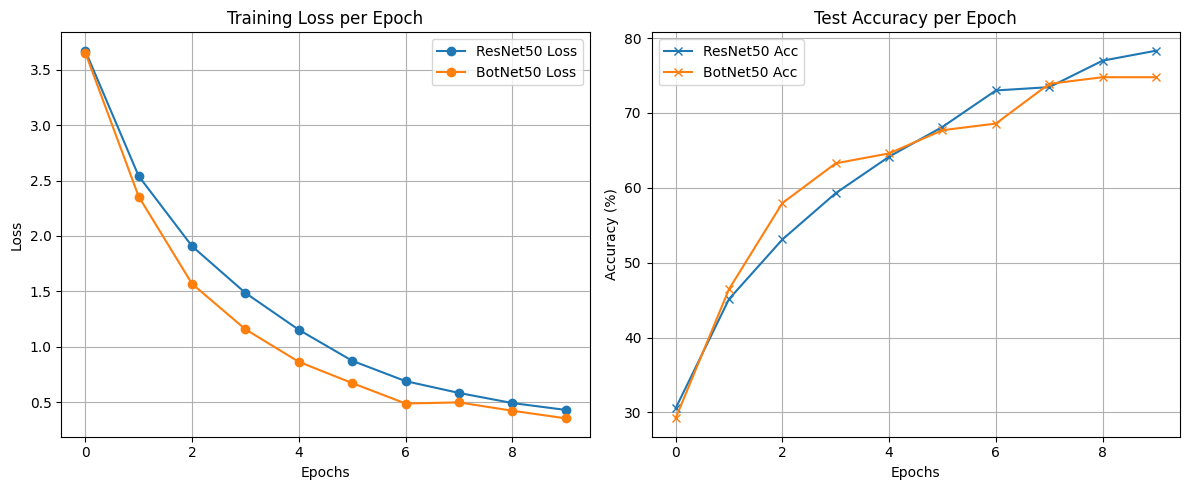

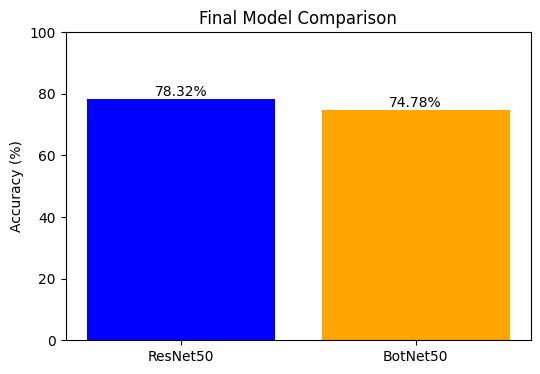

In [28]:
import matplotlib.pyplot as plt

# 1. Modified Train Function to return history
def train_and_validate(model, optimizer, train_loader, test_loader, epochs=5):
    model.train()

    # Lists to store metrics
    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        # --- Training Loop ---
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # --- Validation Loop (Run every epoch for the plot) ---
        acc = evaluate_model(model, test_loader, print_acc=False)
        test_accuracies.append(acc)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Test Acc: {acc:.2f}%")

    return train_losses, test_accuracies

def evaluate_model(model, test_loader, print_acc=True):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    if print_acc:
        print(f"Accuracy: {accuracy:.2f}%")
    return accuracy

# 2. Run Training
print("Training ResNet...")
resnet_loss, resnet_acc_hist = train_and_validate(resnet_model, resnet_optimizer, train_loader, test_loader, epochs=10)

print("\nTraining BotNet...")
botnet_loss, botnet_acc_hist = train_and_validate(botnet_model, botnet_optimizer, train_loader, test_loader, epochs=10)

# ==========================================
# 3. PLOTTING CODE
# ==========================================

# Plot 1: Training Loss Comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(resnet_loss, label='ResNet50 Loss', marker='o')
plt.plot(botnet_loss, label='BotNet50 Loss', marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Test Accuracy Progression
plt.subplot(1, 2, 2)
plt.plot(resnet_acc_hist, label='ResNet50 Acc', marker='x')
plt.plot(botnet_acc_hist, label='BotNet50 Acc', marker='x')
plt.title('Test Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot 3: Final Bar Chart
plt.figure(figsize=(6, 4))
models = ['ResNet50', 'BotNet50']
accuracies = [resnet_acc_hist[-1], botnet_acc_hist[-1]]
bars = plt.bar(models, accuracies, color=['blue', 'orange'])
plt.ylabel('Accuracy (%)')
plt.title('Final Model Comparison')
plt.ylim(0, 100)

# Add numbers on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center')

plt.show()

In [29]:
import numpy as np

def get_display_image(img_tensor):
    """
    Converts a normalized tensor back to a numpy array for plotting.
    """
    # Inverse of the normalization used in transforms
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Move to CPU, convert to numpy, transpose from (C, H, W) to (H, W, C)
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))

    # Un-normalize: (img * std) + mean
    img = std * img + mean

    # Clip values to be between 0 and 1
    img = np.clip(img, 0, 1)
    return img

In [ ]:
import math
import matplotlib.pyplot as plt

# 1. Pick a sample index (e.g., image #5 in the test set)
sample_idx = 5
img_tensor, label = test_dataset[sample_idx]

# 2. Prepare inputs
# Move tensor to GPU for the model
img_tensor_gpu = img_tensor.to(device)

# Get the clean image for display (CPU side)
original_image = get_display_image(img_tensor)

# 3. Run your visualization function
# Note: Ensure 'botnet_model' is the name of your trained model instance
print(f"Visualizing attention for Class ID: {label}")
visualize_attention(botnet_model, img_tensor_gpu, original_image)

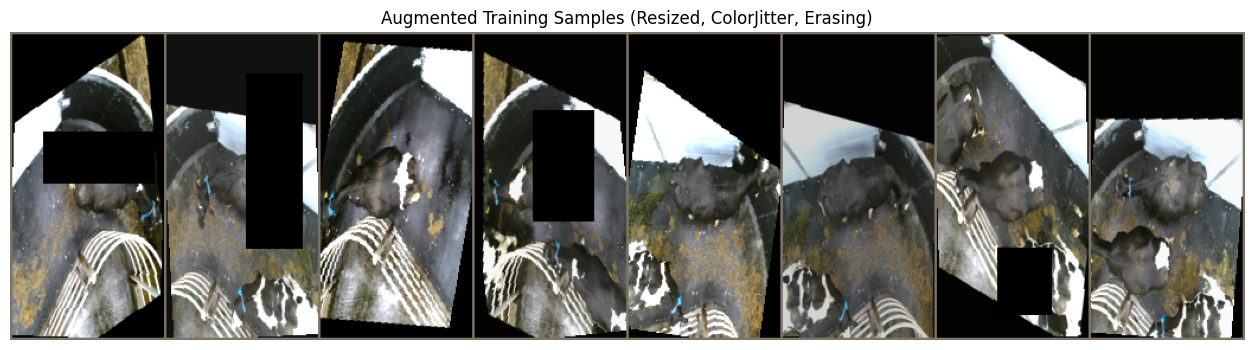

In [33]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

def imshow_batch(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.figure(figsize=(16, 4))
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:8]) # Show top 8
imshow_batch(out, title="Augmented Training Samples (Resized, ColorJitter, Erasing)")

# Part 2: Large Language Diffusion (LLaDA)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 2.2 Data Pipeline & Prompting

In [2]:
# 1. Load Dataset
dataset = load_dataset("gretelai/synthetic_text_to_sql")

# 2. Chat Template
SYSTEM_PROMPT = "You are a Text-to-SQL assistant. Output ONLY the SQL query. Do not add explanations."

def format_example(example, tokenizer):
    user_content = f"Schema:\n{example['schema']}\n\nQuestion:\n{example['sql_prompt']}"

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": example['sql']} # The 'Gold' SQL
    ]

    # Apply template WITHOUT tokenizing yet to find boundaries
    full_text = tokenizer.apply_chat_template(messages, tokenize=False)

    # Simple logic to separate Prompt vs Answer for masking
    # Note: This depends on the specific chat template of the base model
    prompt_part = tokenizer.apply_chat_template(messages[:-1], tokenize=False, add_generation_prompt=True)
    answer_part = example['sql']

    return prompt_part, answer_part

# 3. SQL Normalization
def normalize_sql(query):
    query = query.lower()
    query = query.replace("`", "").replace(";", "")
    query = " ".join(query.split()) # Fix whitespace
    return query

def exact_match_score(pred, truth):
    return 1 if normalize_sql(pred) == normalize_sql(truth) else 0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### 2.3 Model Loading & Forward Process (The Core)

In [3]:
# Load Model with Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

model_name = "GSAI-ML/LLaDA-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    use_cache=False # Important for Diffusion training
)

# Apply LoRA
peft_config = LoraConfig(
    r=16, lora_alpha=32, target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)

The repository GSAI-ML/LLaDA-8B-Instruct contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/GSAI-ML/LLaDA-8B-Instruct .
 You can inspect the repository content at https://hf.co/GSAI-ML/LLaDA-8B-Instruct.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] Y
The repository GSAI-ML/LLaDA-8B-Instruct contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/GSAI-ML/LLaDA-8B-Instruct .
 You can inspect the repository content at https://hf.co/GSAI-ML/LLaDA-8B-Instruct.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] Y


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

**Forward Masking Function:**

In [ ]:
def noisy_batch(input_ids, attention_mask, prompt_lengths, tokenizer, schedule='linear'):
    """
    Applies forward diffusion masking to the ANSWER part of the batch.

    Returns:
        masked_input_ids: input ids with mask tokens applied
        labels: same shape as input_ids, -100 where we don't compute loss
        mask_indices: boolean tensor where tokens were masked (True)
        p_mask: per-sample mask probability tensor (B, 1)

    Notes:
    - We avoid masking prompt tokens (indices < prompt_lengths)
    - We avoid masking padding and special EOS/PAD/BOS tokens
    - We ensure at least one mask per sample (to avoid empty-case instability)
    """
    batch_size, seq_len = input_ids.shape

    device = input_ids.device

    # 1. Sample t uniformly in [0, 1) per sample
    t = torch.rand(batch_size, device=device)

    # 2. Compute p_mask from schedule
    if schedule == 'linear':
        p_mask = t.view(-1, 1)
    elif schedule == 'cosine':
        # A different schedule (example): more aggressive near t=1
        p_mask = (1 - torch.cos(t * math.pi)) / 2
        p_mask = p_mask.view(-1, 1)
    else:
        p_mask = t.view(-1, 1)

    # Expand per-token
    p_mask_exp = p_mask.expand(-1, seq_len)

    # 3. Random mask matrix
    rand_matrix = torch.rand(input_ids.shape, device=device)
    mask_indices = rand_matrix < p_mask_exp

    # 4. Do NOT mask the prompt region for each sample
    for i in range(batch_size):
        mask_indices[i, :prompt_lengths[i]] = False

    # 5. Do NOT mask padding positions (attention_mask==0)
    mask_indices = mask_indices & (attention_mask.bool())

    # 6. Do NOT mask special tokens (EOS, PAD, BOS if present)
    special_ids = set(
        x for x in [
            getattr(tokenizer, 'eos_token_id', None),
            getattr(tokenizer, 'pad_token_id', None),
            getattr(tokenizer, 'bos_token_id', None)
        ] if x is not None
    )
    if len(special_ids) > 0:
        for sid in special_ids:
            mask_indices = mask_indices & (input_ids != sid)

    # 7. Prepare masked inputs and labels
    masked_input_ids = input_ids.clone()
    labels = torch.full_like(input_ids, -100)

    # Apply mask token id where required
    masked_input_ids[mask_indices] = tokenizer.mask_token_id
    labels[mask_indices] = input_ids[mask_indices]

    # 8. Stability: ensure at least one mask per sample (if answer exists)
    for i in range(batch_size):
        if mask_indices[i].sum() == 0:
            start_idx = int(prompt_lengths[i].item())
            if start_idx < seq_len:
                # choose a random token within the answer span that is not special/pad
                candidate_idx = torch.randint(start_idx, seq_len, (1,), device=device).item()
                # if the chosen pos is pad or special, try to find a valid one
                # linear scan fallback (small overhead)
                if input_ids[i, candidate_idx] in special_ids or attention_mask[i, candidate_idx] == 0:
                    # find first non-special after start_idx
                    candidates = (attention_mask[i].bool() & ~torch.isin(input_ids[i], torch.tensor(list(special_ids), device=device))).nonzero(as_tuple=False)
                    candidates = candidates[candidates[:,0] >= start_idx]
                    if len(candidates) > 0:
                        candidate_idx = int(candidates[0,0].item())
                    else:
                        # nothing to mask, continue
                        continue
                mask_indices[i, candidate_idx] = True
                masked_input_ids[i, candidate_idx] = tokenizer.mask_token_id
                labels[i, candidate_idx] = input_ids[i, candidate_idx]

    return masked_input_ids, labels, mask_indices, p_mask.view(-1, 1)

### 2.3.4 Training Loop

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=2e-4)

def prepare_batch(examples, tokenizer):
    """Prepare a batch of examples for training"""
    input_ids_list = []
    prompt_lengths = []

    for example in examples:
        prompt, answer = format_example(example, tokenizer)
        full_text = prompt + answer

        # Tokenize
        tokens = tokenizer(full_text, return_tensors='pt', padding=False)
        input_ids = tokens['input_ids'].squeeze()

        # Find prompt length
        prompt_tokens = tokenizer(prompt, return_tensors='pt', padding=False)['input_ids'].squeeze()
        prompt_len = len(prompt_tokens)

        input_ids_list.append(input_ids)
        prompt_lengths.append(prompt_len)

    # Pad to max length
    max_len = max(len(ids) for ids in input_ids_list)
    padded_ids = []
    attention_masks = []

    for ids in input_ids_list:
        pad_len = max_len - len(ids)
        padded = torch.cat([ids, torch.full((pad_len,), tokenizer.pad_token_id)])
        mask = torch.cat([torch.ones(len(ids)), torch.zeros(pad_len)])
        padded_ids.append(padded)
        attention_masks.append(mask)

    batch_input_ids = torch.stack(padded_ids)
    batch_attention_mask = torch.stack(attention_masks)
    batch_prompt_lengths = torch.tensor(prompt_lengths)

    return batch_input_ids, batch_attention_mask, batch_prompt_lengths

def train_step(batch, model, optimizer, tokenizer, accumulate_steps=1):
    input_ids, att_mask, prompt_lens = prepare_batch(batch, tokenizer)
    input_ids, att_mask, prompt_lens = input_ids.to(device), att_mask.to(device), prompt_lens.to(device)

    # Apply Noise: now returns mask indices also
    masked_ids, labels, mask_indices, p_mask = noisy_batch(input_ids, att_mask, prompt_lens, tokenizer)

    outputs = model(input_ids=masked_ids, attention_mask=att_mask)
    logits = outputs.logits

    # Per-token loss (we already place -100 in labels where not masked)
    loss_fct = nn.CrossEntropyLoss(reduction='none')
    loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))

    # Reshape and aggregate per sample
    batch_size = input_ids.shape[0]
    loss = loss.view(batch_size, -1)

    num_masked = mask_indices.sum(dim=1).float()
    safe_num = num_masked.clone()
    safe_num[safe_num == 0] = 1.0

    loss_per_seq = loss.sum(dim=1)
    loss_per_mask = loss_per_seq / safe_num

    # Reweighting coefficient: inverse of p_mask (samples with few masks are upweighted)
    weights = 1.0 / (p_mask.squeeze() + 1e-6)

    weighted_loss = loss_per_mask * weights * (num_masked > 0).float()

    final_loss = weighted_loss.mean()

    # Backward (no optimizer.step here if using accumulation outside)
    final_loss.backward()

    return final_loss.item()



### 2.4 Block Diffusion Sampling (Generation)

In [ ]:
@torch.no_grad()
def generate_block_diffusion(model, tokenizer, prompt_text, steps=32, gen_len=64, block_size=None):
    """
    Block diffusion sampler with conservative/robust behavior.

    - prompt_text: full prompt (system+user) already in chat format
    - steps: number of iteration steps (coarse control)
    - gen_len: length of the generated answer in tokens
    - block_size: how many tokens to commit each step; if None: commit ceil(gen_len / steps)

    Returns the generated answer string (only the generated part)
    """
    # Tokenize prompt, prepare initial masked generation region
    prompt_ids = tokenizer.encode(prompt_text, return_tensors='pt', add_special_tokens=False).to(device)
    mask_ids = torch.full((1, gen_len), tokenizer.mask_token_id, device=device, dtype=torch.long)
    input_ids = torch.cat([prompt_ids, mask_ids], dim=1)

    L = input_ids.shape[1]
    prompt_len = prompt_ids.shape[1]
    gen_indices = list(range(prompt_len, L))

    if block_size is None:
        block_size = max(1, math.ceil(gen_len / steps))

    unknown_set = set(gen_indices)

    for step in range(steps):
        outputs = model(input_ids)
        logits = outputs.logits  # (1, L, V)

        # Softmax over vocab for the positions we care about
        probs = torch.softmax(logits, dim=-1)
        confidences, predicted_ids = torch.max(probs, dim=-1)  # (1, L)

        # Candidate list only for unknown positions
        candidates = []
        for idx in list(unknown_set):
            score = float(confidences[0, idx].item())
            token = int(predicted_ids[0, idx].item())
            candidates.append((score, idx, token))

        if not candidates:
            break

        # Sort by confidence and commit top-k
        candidates.sort(key=lambda x: x[0], reverse=True)
        k = min(block_size, len(candidates))
        topk = candidates[:k]

        for score, idx, token in topk:
            input_ids[0, idx] = token
            unknown_set.discard(idx)

        # Early stop if all filled
        if len(unknown_set) == 0:
            break

    # Decode and post-process: decode generated region only
    generated_ids = input_ids[0, prompt_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return generated_text

In [11]:
class TextToSQLDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_len=512):
        self.data = dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

        # System Prompt
        self.system_prompt = (
            "You are a Text-to-SQL assistant. Output ONLY the SQL query. "
            "Do not add explanations."
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # --- FIX: استفاده از نام ستون‌های صحیح دیتاست gretelai ---
        schema = item['sql_context']
        question = item['sql_prompt']

        # ساخت محتوای کاربر
        user_content = f"Schema:\n{schema}\n\nQuestion:\n{question}\n"

        messages = [
            {"role": "system", "content": self.system_prompt},
            {"role": "user", "content": user_content}
        ]

        # اعمال تمپلیت چت (فقط روی پرامپت)
        prompt_text = self.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

        # متن پاسخ
        answer_text = item['sql']

        # توکنایز جداگانه برای تشخیص مرزها
        prompt_ids = self.tokenizer.encode(prompt_text, add_special_tokens=False)
        answer_ids = self.tokenizer.encode(answer_text, add_special_tokens=False)

        # اضافه کردن EOS به پاسخ
        answer_ids += [self.tokenizer.eos_token_id]

        # چسباندن به هم
        input_ids = prompt_ids + answer_ids

        # کوتاه کردن (Truncation) در صورت نیاز
        if len(input_ids) > self.max_len:
            input_ids = input_ids[:self.max_len]

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "prompt_length": len(prompt_ids)
        }
def collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    prompt_lens = [item['prompt_length'] for item in batch]

    # Dynamic padding
    padded_inputs = torch.nn.utils.rnn.pad_sequence(
        input_ids, batch_first=True, padding_value=tokenizer.pad_token_id
    )

    # Create Attention Mask (1 for real tokens, 0 for pad)
    attention_mask = (padded_inputs != tokenizer.pad_token_id).long()

    return padded_inputs, attention_mask, torch.tensor(prompt_lens)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_linear_schedule_with_warmup
raw_dataset = load_dataset("gretelai/synthetic_text_to_sql")

# -----------------------------
# 1) Basic Stats & Filtering
# -----------------------------
def extract_tables_only(schema_text):
    """Keep only lines that start with 'table' (case-insensitive)."""
    lines = [l.strip() for l in schema_text.splitlines() if l.strip()]
    table_lines = [l for l in lines if l.lower().startswith('table')]
    if len(table_lines) == 0:
        # fallback: keep up to first 2 lines
        return '\n'.join(lines[:2])
    return '\n'.join(table_lines)

# Quick stat computation (tokens and chars) on a sample of the dataset
def compute_dataset_stats(split, tokenizer, sample_n=1000):
    n = min(sample_n, len(split))
    schema_lens_chars = []
    question_lens_chars = []
    schema_lens_tokens = []
    question_lens_tokens = []
    it = split.select(range(n)) if n < len(split) else split
    for ex in it:
        schema = ex.get('sql_context', '')
        question = ex.get('sql_prompt', '')
        schema_lens_chars.append(len(schema))
        question_lens_chars.append(len(question))
        schema_lens_tokens.append(len(tokenizer(schema, add_special_tokens=False)['input_ids']))
        question_lens_tokens.append(len(tokenizer(question, add_special_tokens=False)['input_ids']))
    return {
        'schema_chars_avg': np.mean(schema_lens_chars),
        'question_chars_avg': np.mean(question_lens_chars),
        'schema_tokens_avg': np.mean(schema_lens_tokens),
        'question_tokens_avg': np.mean(question_lens_tokens),
    }

print('Dataset stats (train sample):')
stats = compute_dataset_stats(raw_dataset['train'], tokenizer, sample_n=500)
print(stats)

# -----------------------------
# 2) Filter / Truncate strategy
# -----------------------------
MAX_LEN = 384  # Keep conservative to fit into memory; you can increase with more VRAM

# Preprocess: replace long schemas with table-only condensed version
def preprocess_example(example):
    schema = example.get('sql_context', '')
    question = example.get('sql_prompt', '')
    answer = example.get('sql', '')

    # If schema is long, keep only table definitions
    if len(schema) > 500:  # char threshold
        schema = extract_tables_only(schema)

    # Build prompt text to measure final token length
    system_prompt = (
        "You are a Text-to-SQL assistant. Output ONLY the SQL query. "
        "Do not add explanations."
    )
    user_content = f"Schema:\n{schema}\n\nQuestion:\n{question}\n"
    prompt_text = tokenizer.apply_chat_template(
        [{"role":"system","content":system_prompt}, {"role":"user","content":user_content}],
        tokenize=False, add_generation_prompt=True
    )

    # If still too long by tokens, drop this example (rare)
    total_tokens = len(tokenizer(prompt_text + answer, add_special_tokens=False)['input_ids'])
    if total_tokens > MAX_LEN:
        return None  # signal to drop

    return {
        'sql_context': schema,
        'sql_prompt': question,
        'sql': answer
    }

# Apply preprocessing and filter out bad examples
def filter_and_prepare(split):
    cleaned = []
    for ex in split:
        r = preprocess_example(ex)
        if r is not None:
            cleaned.append(r)
    return cleaned

print('Preprocessing and filtering dataset...')
train_clean = filter_and_prepare(raw_dataset['train'])
test_clean = filter_and_prepare(raw_dataset['test'])

print(f'After filtering: train={len(train_clean)}, test={len(test_clean)}')

# Ensure minimum sizes
MIN_TRAIN = 1000
MIN_TEST = 300
if len(train_clean) < MIN_TRAIN:
    raise RuntimeError(f"Not enough training examples after filtering: {len(train_clean)} < {MIN_TRAIN}")
if len(test_clean) < MIN_TEST:
    raise RuntimeError(f"Not enough test examples after filtering: {len(test_clean)} < {MIN_TEST}")

# We will build small validation split from train
VAL_PCT = 0.1
val_cut = int(len(train_clean) * VAL_PCT)
val_clean = train_clean[:val_cut]
train_clean = train_clean[val_cut:]

print(f'Train/Val/Test sizes: {len(train_clean)}/{len(val_clean)}/{len(test_clean)}')

# Wrap cleaned lists in Dataset-lite objects for DataLoader
class ListDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

train_ds = TextToSQLDataset(ListDataset(train_clean), tokenizer, max_len=MAX_LEN)
val_ds = TextToSQLDataset(ListDataset(val_clean), tokenizer, max_len=MAX_LEN)
test_ds = TextToSQLDataset(ListDataset(test_clean), tokenizer, max_len=MAX_LEN)

BATCH_SIZE = 1
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)

optimizer = optim.AdamW(model.parameters(), lr=2e-4)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=50, num_training_steps=len(train_loader))
criterion = nn.CrossEntropyLoss(reduction='none') # Per-token loss for reweighting


In [17]:
# تعمیر مجدد توکنایزر (چون دوباره لود شده بود)
if tokenizer.mask_token_id is None:
    print("⚠️ Mask token missing! Setting mask_token to EOS token.")
    tokenizer.mask_token = tokenizer.eos_token
    tokenizer.mask_token_id = tokenizer.eos_token_id

# اطمینان از اینکه پد توکن هم ست شده باشد
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Fixed! Mask Token ID: {tokenizer.mask_token_id}")

⚠️ Mask token missing! Setting mask_token to EOS token.
Fixed! Mask Token ID: 126081


In [ ]:
# ==========================================
# 1. OPTIMIZED CONFIGURATION
# ==========================================
BATCH_SIZE = 1            # small batch to avoid OOM
GRAD_ACCUM_STEPS = 4      # emulate larger batch with accumulation
MAX_LEN = 384

# Use previously created train_loader/val_loader/test_loader
# Recompute scheduler with accumulation steps in mind
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=50, num_training_steps=(len(train_loader) // GRAD_ACCUM_STEPS) + 1
)

# ==========================================
# 3. MEMORY-EFFICIENT & STABLE TRAINING LOOP
# ==========================================
print("Starting Memory-Efficient Training (Question 2)...")
model.train()

EPOCHS = 1
best_val = float('inf')
optimizer.zero_grad()

for epoch in range(EPOCHS):
    total_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for step, (batch_input_ids, batch_att_mask, batch_prompt_lens) in enumerate(progress_bar):
        batch_input_ids = batch_input_ids.to(device)
        batch_att_mask = batch_att_mask.to(device)
        batch_prompt_lens = batch_prompt_lens.to(device)

        # Apply Noise (function now returns mask_indices too)
        masked_input, labels, mask_indices, p_mask = noisy_batch(
            batch_input_ids, batch_att_mask, batch_prompt_lens, tokenizer, schedule='linear'
        )
        masked_input = masked_input.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(input_ids=masked_input, attention_mask=batch_att_mask)
        logits = outputs.logits

        # Per-token loss
        loss_per_token = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))
        loss_per_token = loss_per_token.view(batch_input_ids.shape[0], -1)

        # Number of masked tokens per sample
        num_masked_tokens = (mask_indices).sum(dim=1).float()  # not including -100 positions

        # Reweighting: weight inversely proportional to p_mask (samples with few masks get higher weight)
        # This balances contributions across different t
        eps = 1e-6
        weights = 1.0 / (p_mask.squeeze() + eps)

        # Compute averaged loss per masked token (stable when no masked tokens)
        loss_per_seq = loss_per_token.sum(dim=1)
        safe_num = num_masked_tokens.clone()
        safe_num[safe_num == 0] = 1.0  # avoid division by zero
        loss_per_mask = loss_per_seq / safe_num

        weighted_loss = loss_per_mask * weights

        # If a sample had zero masked tokens, its loss contribution should be zero
        weighted_loss = weighted_loss * (num_masked_tokens > 0).float()

        final_loss = weighted_loss.mean()

        # Normalize for gradient accumulation
        final_loss = final_loss / GRAD_ACCUM_STEPS

        final_loss.backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += (final_loss.item() * GRAD_ACCUM_STEPS)
        progress_bar.set_postfix({'loss': total_loss / (step+1)})

    # --- Validation check (simple) ---
    model.eval()
    with torch.no_grad():
        val_losses = []
        for v_input_ids, v_att_mask, v_prompt_lens in val_loader:
            v_input_ids = v_input_ids.to(device)
            v_att_mask = v_att_mask.to(device)
            v_prompt_lens = v_prompt_lens.to(device)
            m_input, v_labels, v_mask_idx, v_p = noisy_batch(v_input_ids, v_att_mask, v_prompt_lens, tokenizer)
            out = model(input_ids=m_input.to(device), attention_mask=v_att_mask)
            v_logits = out.logits
            v_loss_t = criterion(v_logits.view(-1, v_logits.size(-1)), v_labels.view(-1))
            v_loss_t = v_loss_t.view(v_input_ids.shape[0], -1)
            v_num_masked = (v_mask_idx).sum(dim=1).float()
            v_loss_seq = v_loss_t.sum(dim=1) / (v_num_masked + 1e-6)
            # weight by 1/p as in training
            v_weights = 1.0 / (v_p.squeeze() + 1e-6)
            v_loss = (v_loss_seq * v_weights * (v_num_masked>0).float()).mean()
            val_losses.append(v_loss.item())
        mean_val = np.mean(val_losses) if len(val_losses)>0 else 0.0
    print(f"Epoch {epoch+1} finished. Train loss avg: {total_loss/(len(train_loader)+1):.4f}, Val loss: {mean_val:.4f}")

    # Basic checkpointing: save LoRA adapter weights if improved
    if mean_val < best_val:
        best_val = mean_val
        try:
            model.save_pretrained('./best_lora_checkpoint')
            print('Saved best checkpoint (./best_lora_checkpoint)')
        except Exception as e:
            print('Warning: could not save checkpoint:', e)
    model.train()

print("Training Complete.")

Starting Memory-Efficient Training...


Epoch 1:   2%|▏         | 1931/100000 [21:35<17:01:13,  1.60it/s, loss=0.134]

### 2.4.3 Evaluation & Post-processing

In [ ]:
def normalize_sql(query):
    if query is None:
        return ""
    q = query.lower()
    q = q.replace('`', '').replace('"', '').replace("'", '')
    q = q.replace('\n', ' ')
    q = q.replace(';', '')
    q = ' '.join(q.split())
    return q


def exact_match_score(pred, truth):
    return 1 if normalize_sql(pred) == normalize_sql(truth) else 0


def post_process_sql(text):
    if not text:
        return ''
    text_up = text.upper()
    if 'SELECT' in text_up:
        start = text_up.find('SELECT')
        # find final semicolon after SELECT
        end = text.find(';', start)
        if end != -1:
            return text[start:end+1].strip()
        else:
            return text[start:].strip()
    # If SELECT not present, return cleaned text
    return text.strip()


def evaluate_pipeline(dataset_list, model, tokenizer, num_samples=200, show_examples=10):
    """Evaluate on up to num_samples examples from dataset_list (which can be an HF split or list)
    Computes Normalized Exact Match and prints a few examples."""
    total = 0
    correct = 0
    examples = []

    for i, example in enumerate(dataset_list):
        if i >= num_samples:
            break
        prompt, gold_sql = format_example(example, tokenizer)
        raw_output = generate_block_diffusion(model, tokenizer, prompt, steps=32, gen_len=128)
        pred_sql = post_process_sql(raw_output)

        nm = exact_match_score(pred_sql, gold_sql)
        correct += nm
        total += 1

        if len(examples) < show_examples:
            examples.append((prompt, pred_sql, gold_sql))

    acc = (correct / total) * 100 if total>0 else 0.0
    print(f"Normalized Exact Match over {total} samples: {acc:.2f}%")
    print('\nSome examples:')
    for pr, pred, gold in examples:
        print('---')
        print('Prompt:')
        print(pr)
        print('\nPredicted SQL:')
        print(pred)
        print('\nGold SQL:')
        print(gold)
        print('---\n')

    return acc, examples

# Example evaluation
# test_data = dataset['test']
# evaluate_pipeline(test_data, model, tokenizer)

### Example Usage

In [ ]:
# Example for Re-ID visualization
# img, label = test_dataset[0]
# original_img = T.ToPILImage()(img)
# visualize_attention(botnet_model, img, original_img)

# Example for LLaDA generation & evaluation
# Pick a small test example
example = raw_dataset['test'][0]
prompt, _ = format_example(example, tokenizer)
print('Sample prompt (truncated):', prompt[:400])

# Quick generation demo (small gen_len for speed)
# generated = generate_block_diffusion(model, tokenizer, prompt, steps=16, gen_len=64)
# print('Generated SQL:', post_process_sql(generated))

# Run a small evaluation on the test split (200 samples) - uncomment to run
# acc, examples = evaluate_pipeline(test_clean, model, tokenizer, num_samples=200, show_examples=10)
# print('Eval acc:', acc)

# Note: full training/eval will take significant time and VRAM. Use the checkpoint at './best_lora_checkpoint' if saved.